In [1]:
import os; WORKDIR = f"{os.getcwd()}/.."
import sys; sys.path.append(f"{WORKDIR}/libPython")
import ROOT

from torch_geometric.loader import DataLoader
from sklearn.utils import shuffle
from DataManager import rtfileToDataList, GraphDataset

import matplotlib.pyplot as plt
import networkx as nx

Welcome to JupyROOT 6.28/04


In [2]:
maxSize = 100
SIGNAL = "MHc-130_MA-90"
BACKGROUND = "ttZ"

In [4]:
rtSig = ROOT.TFile.Open(f"{WORKDIR}/DATA/{SIGNAL}.root")
rtBkg = ROOT.TFile.Open(f"{WORKDIR}/DATA/{BACKGROUND}.root")

sigDataList = shuffle(rtfileToDataList(rtSig, isSignal=True, returnParticleTypes=True, maxSize=maxSize), random_state=42); rtSig.Close()
bkgDataList = shuffle(rtfileToDataList(rtBkg, isSignal=False, returnParticleTypes=True, maxSize=maxSize), random_state=42); rtBkg.Close()
dataList = shuffle(sigDataList+bkgDataList, random_state=42)

trainset = GraphDataset(dataList[:int(len(dataList)*0.6)])
validset = GraphDataset(dataList[int(len(dataList)*0.6):int(len(dataList)*0.7)])
testset  = GraphDataset(dataList[int(len(dataList)*0.7):])

@@@@ no. of dataList ends with 100
@@@@ no. of dataList ends with 100


In [5]:
data = trainset[0]
print(data)

Data(x=[10, 8], edge_index=[2, 90], y=[1], edge_attribute=[90, 1], particleTypes=[10])


Data(x=[7, 8], edge_index=[2, 42], y=1, edge_attribute=[42, 1], particleTypes=[7])


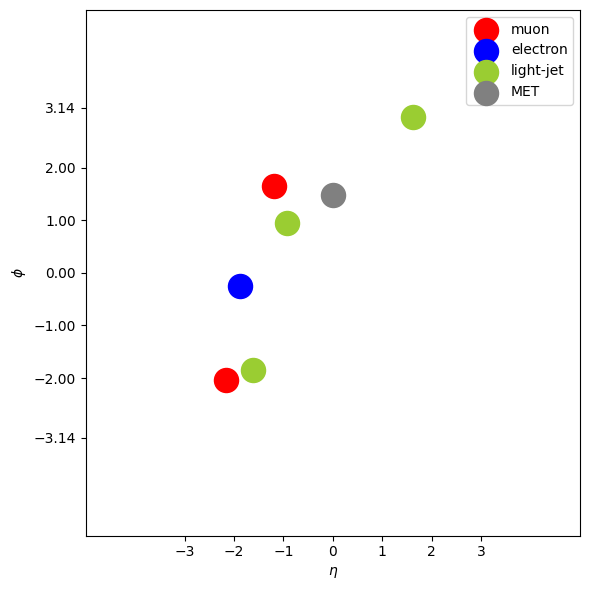

In [31]:
data = sigDataList[3]
print(data)
G = nx.Graph()
positions = {}
muons = []
electrons = []
jets = []
bjets = []
METv = []
for i, features in enumerate(data.x):
    thisParticle = ROOT.TLorentzVector()
    thisParticle.SetPxPyPzE(features[1], features[2], features[3], features[0])
    positions[i] = (thisParticle.Eta(), thisParticle.Phi())
for i, particleType in enumerate(data.particleTypes):
    if particleType == "muon": muons.append(i)
    if particleType == "electron": electrons.append(i)
    if particleType == "light-jet": jets.append(i)
    if particleType == "heavy-jet": bjets.append(i)
    if particleType == "METv": METv.append(i)
G.add_nodes_from(positions.keys())

plt.figure(figsize=(6, 6))
nx.draw_networkx_nodes(G, positions, nodelist=muons, node_color="red", label="muon")
nx.draw_networkx_nodes(G, positions, nodelist=electrons, node_color="blue", label="electron")
nx.draw_networkx_nodes(G, positions, nodelist=jets, node_color="yellowgreen", label="light-jet")
nx.draw_networkx_nodes(G, positions, nodelist=bjets, node_color="green", label="heavy-jet")
nx.draw_networkx_nodes(G, positions, nodelist=METv, node_color="gray", label="MET")
plt.legend(loc="upper right")
plt.xlabel(r"$\eta$")
plt.ylabel(r"$\phi$")
plt.xlim(-5, 5)
plt.ylim(-5, 5)
plt.xticks([-3., -2., -1., 0., 1., 2., 3])
plt.yticks([-3.14, -2., -1., 0., 1., 2., 3.14])
plt.tick_params(left=True, bottom=True, labelleft=True, labelbottom=True)
plt.tight_layout()
plt.savefig("../outputs/ex3/plots/signal_3.png")

Data(x=[8, 8], edge_index=[2, 56], y=0, edge_attribute=[56, 1], particleTypes=[8])


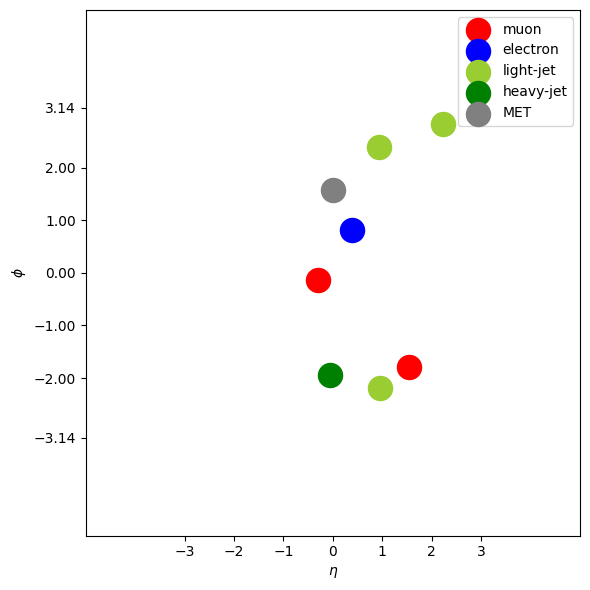

In [35]:
data = bkgDataList[3]
print(data)
G = nx.Graph()
positions = {}
muons = []
electrons = []
jets = []
bjets = []
METv = []
for i, features in enumerate(data.x):
    thisParticle = ROOT.TLorentzVector()
    thisParticle.SetPxPyPzE(features[1], features[2], features[3], features[0])
    positions[i] = (thisParticle.Eta(), thisParticle.Phi())
for i, particleType in enumerate(data.particleTypes):
    if particleType == "muon": muons.append(i)
    if particleType == "electron": electrons.append(i)
    if particleType == "light-jet": jets.append(i)
    if particleType == "heavy-jet": bjets.append(i)
    if particleType == "METv": METv.append(i)
G.add_nodes_from(positions.keys())

plt.figure(figsize=(6, 6))
nx.draw_networkx_nodes(G, positions, nodelist=muons, node_color="red", label="muon")
nx.draw_networkx_nodes(G, positions, nodelist=electrons, node_color="blue", label="electron")
nx.draw_networkx_nodes(G, positions, nodelist=jets, node_color="yellowgreen", label="light-jet")
nx.draw_networkx_nodes(G, positions, nodelist=bjets, node_color="green", label="heavy-jet")
nx.draw_networkx_nodes(G, positions, nodelist=METv, node_color="gray", label="MET")
plt.legend(loc="upper right")
plt.xlabel(r"$\eta$")
plt.ylabel(r"$\phi$")
plt.xlim(-5, 5)
plt.ylim(-5, 5)
plt.xticks([-3., -2., -1., 0., 1., 2., 3])
plt.yticks([-3.14, -2., -1., 0., 1., 2., 3.14])
plt.tick_params(left=True, bottom=True, labelleft=True, labelbottom=True)
plt.tight_layout()
plt.savefig("../outputs/ex3/plots/background_3.png")